# Phase 7 — Correlation & Cross-Stock Analysis

This notebook compares the Pearson correlation of daily returns for AAPL, MSFT, GOOGL, AMZN, and NVDA. Correlation describes the strength of a linear relationship between return movements; it does not establish causation or provide an investment recommendation.

## Objective

Load the Phase 4 daily-return files, align them by date, calculate full-period and trailing 60-trading-day correlations, and create descriptive visualizations.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.correlation_analysis import (
    FIGURES_DIR, ROLLING_WINDOW, TICKERS, build_correlation_summary,
    build_pair_rankings, build_return_matrix, calculate_rolling_correlations,
    save_heatmap, save_pair_comparison, save_rolling_plot,
)

## Load and align daily returns

In [2]:
return_matrix = build_return_matrix()
return_matrix.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA
Date,,,,,
2021-08-16,NaN,NaN,NaN,NaN,NaN
2021-08-17,-0.006154,-0.005160,-0.011915,-0.017287,-0.024662
2021-08-18,-0.025501,-0.008018,-0.008872,-0.012566,-0.021482
2021-08-19,0.002323,0.020775,0.001705,-0.004208,0.039811
2021-08-20,0.010157,0.025575,0.012894,0.003827,0.051419


## Correlation matrix

In [3]:
correlation_matrix = return_matrix.corr(method='pearson')
correlation_matrix.round(4)

,AAPL,MSFT,GOOGL,AMZN,NVDA
AAPL,1.0000,0.5316,0.5177,0.4935,0.4786
MSFT,0.5316,1.0000,0.5481,0.6104,0.5673
GOOGL,0.5177,0.5481,1.0000,0.6209,0.5009
AMZN,0.4935,0.6104,0.6209,1.0000,0.5300
NVDA,0.4786,0.5673,0.5009,0.5300,1.0000


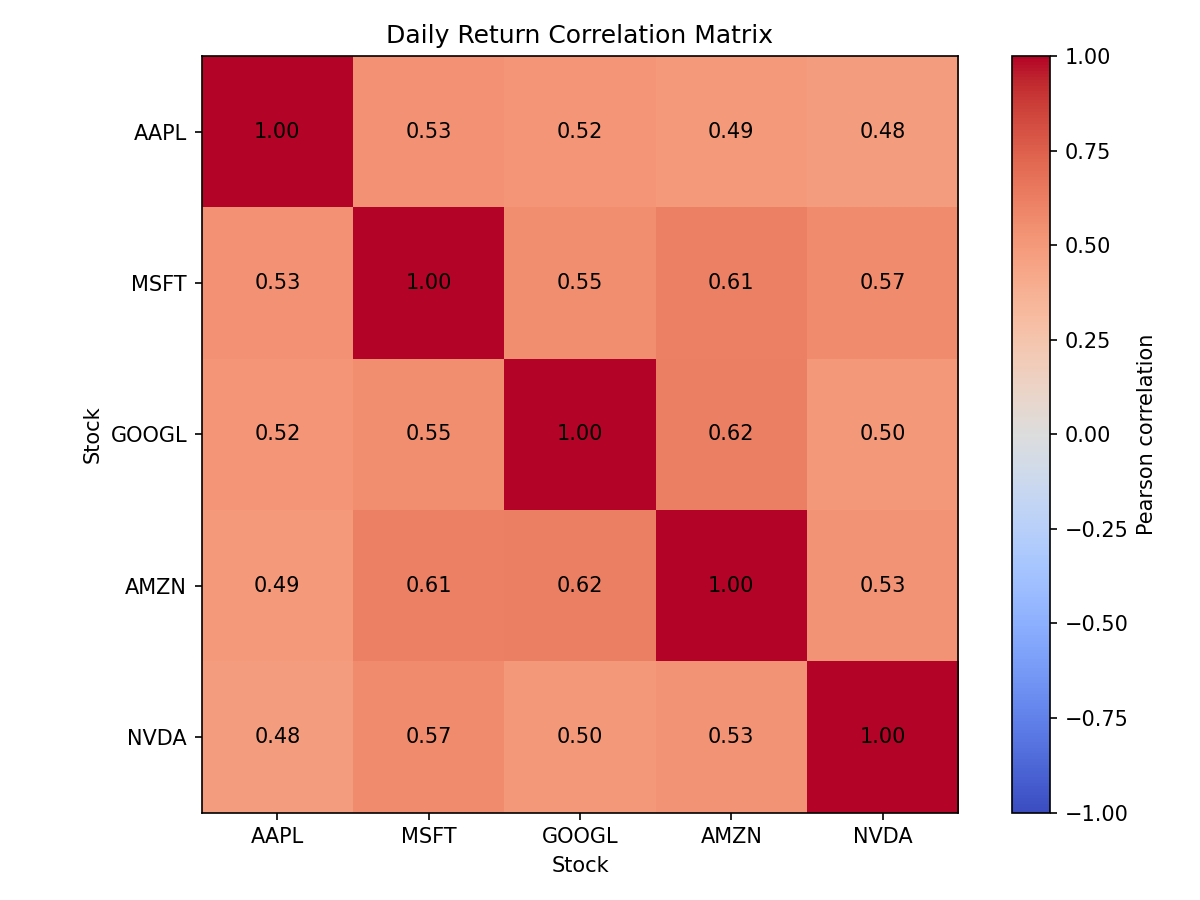

In [4]:
save_heatmap(correlation_matrix)
from IPython.display import Image, display
display(Image(filename=str(FIGURES_DIR / 'correlation_heatmap.png')))

## Pairwise correlation ranking

In [5]:
pair_rankings = build_pair_rankings(correlation_matrix)
pair_rankings.round(4)

,Stock A,Stock B,Correlation
0,GOOGL,AMZN,0.6209
1,MSFT,AMZN,0.6104
2,MSFT,NVDA,0.5673
3,MSFT,GOOGL,0.5481
4,AAPL,MSFT,0.5316
5,AMZN,NVDA,0.5300
6,AAPL,GOOGL,0.5177
7,GOOGL,NVDA,0.5009
8,AAPL,AMZN,0.4935
9,AAPL,NVDA,0.4786


Highest correlation: GOOGL-AMZN (0.6209)
Lowest correlation: AAPL-NVDA (0.4786)


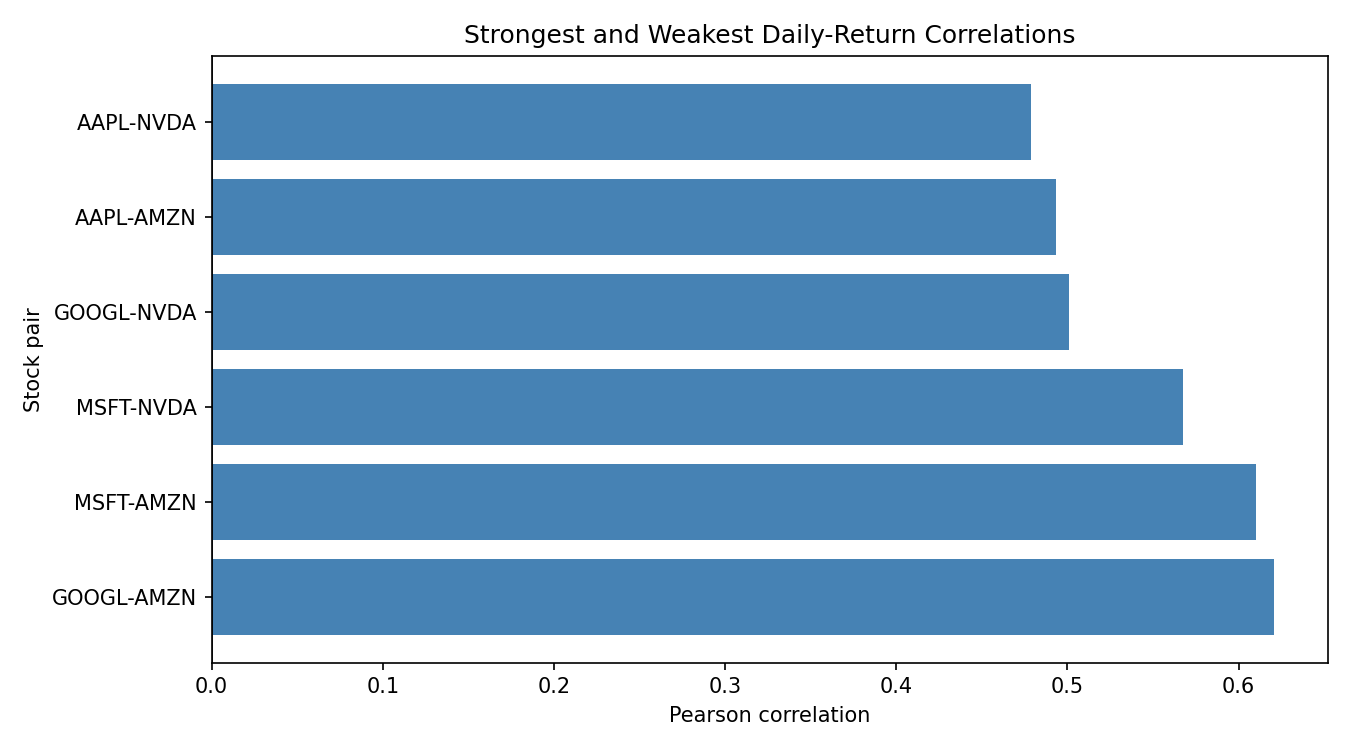

In [6]:
highest_pair = pair_rankings.iloc[0]
lowest_pair = pair_rankings.iloc[-1]
print(f"Highest correlation: {highest_pair['Stock A']}-{highest_pair['Stock B']} ({highest_pair['Correlation']:.4f})")
print(f"Lowest correlation: {lowest_pair['Stock A']}-{lowest_pair['Stock B']} ({lowest_pair['Correlation']:.4f})")
save_pair_comparison(pair_rankings)
display(Image(filename=str(FIGURES_DIR / 'correlation_pair_comparison.png')))

## Rolling correlation

In [7]:
rolling_correlations = calculate_rolling_correlations(return_matrix)
correlation_summary = build_correlation_summary(correlation_matrix, rolling_correlations)
correlation_summary.round(4)

,Pair,Full-period Correlation,Minimum Rolling Correlation,Maximum Rolling Correlation,Average Rolling Correlation
0,AAPL-MSFT,0.5316,-0.0587,0.8854,0.5035
1,AAPL-GOOGL,0.5177,-0.1484,0.8709,0.4907
2,AAPL-AMZN,0.4935,-0.1899,0.8506,0.4634
3,AAPL-NVDA,0.4786,-0.0945,0.8482,0.4283
4,MSFT-GOOGL,0.5481,-0.0893,0.9447,0.5242
5,MSFT-AMZN,0.6104,0.2097,0.8663,0.5882
6,MSFT-NVDA,0.5673,0.0472,0.8467,0.5557
7,GOOGL-AMZN,0.6209,0.1511,0.8954,0.5831
8,GOOGL-NVDA,0.5009,0.0814,0.8835,0.4666
9,AMZN-NVDA,0.5300,0.0153,0.8589,0.4940


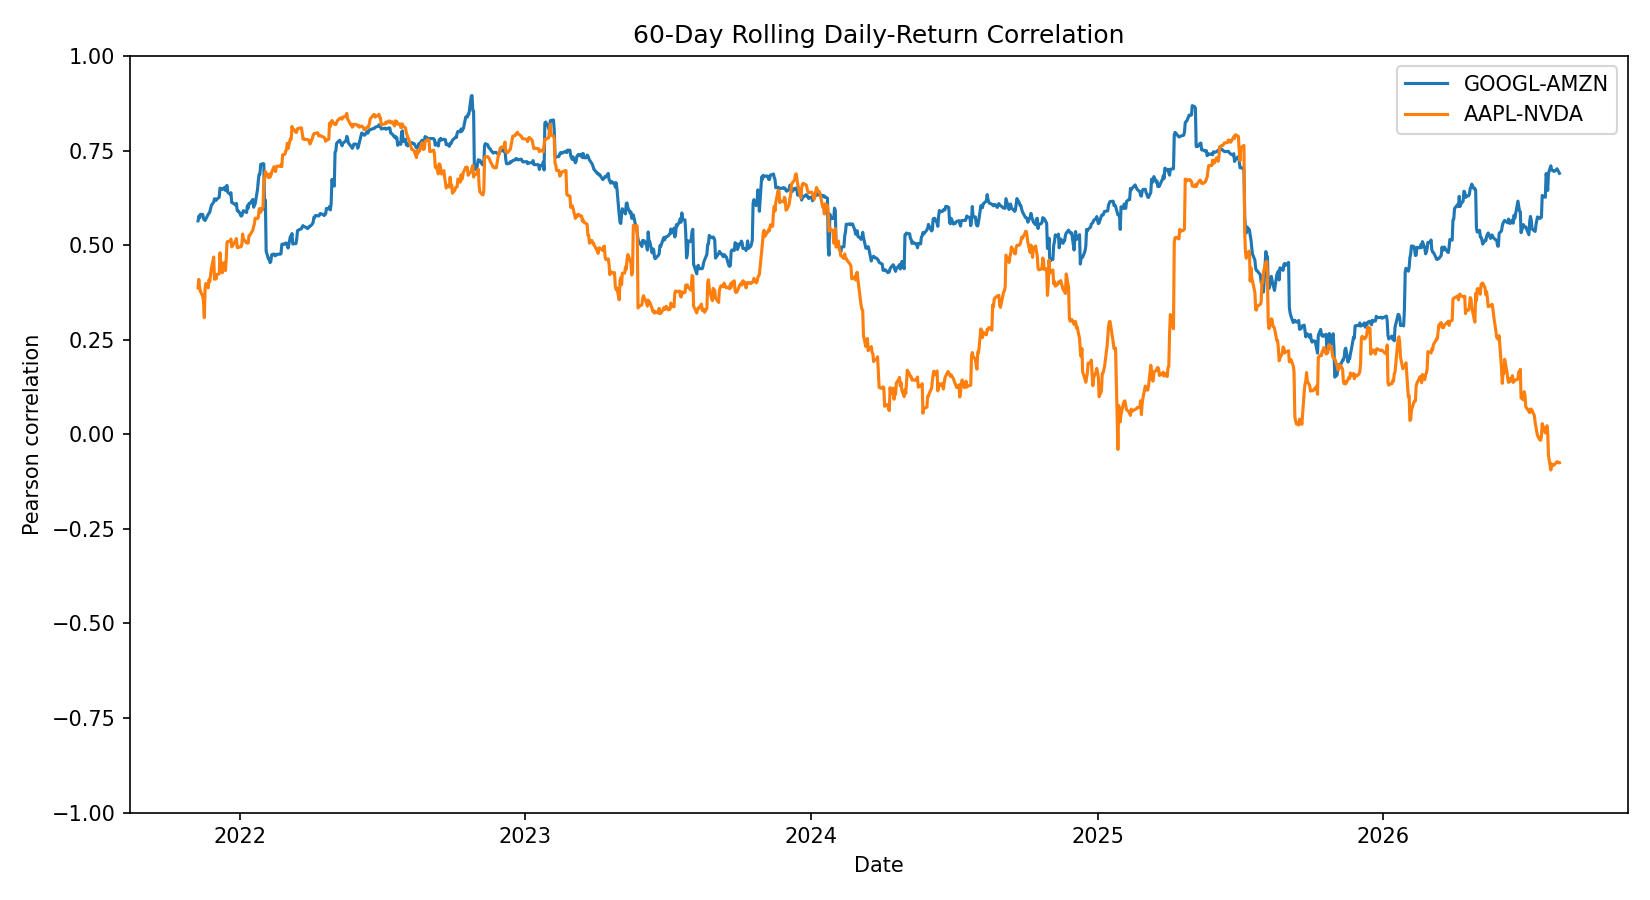

In [8]:
save_rolling_plot(rolling_correlations, pair_rankings)
display(Image(filename=str(FIGURES_DIR / 'correlation_rolling_pairs.png')))

## Key observations

The strongest and weakest relationships below are descriptive results from the calculated daily-return correlations. They should not be interpreted as proof of causation, guaranteed diversification, or investment suitability.

In [9]:
print(f"The strongest full-period correlation was {highest_pair['Stock A']}-{highest_pair['Stock B']} ({highest_pair['Correlation']:.4f}).")
print(f"The weakest full-period correlation was {lowest_pair['Stock A']}-{lowest_pair['Stock B']} ({lowest_pair['Correlation']:.4f}).")
print(f"Rolling correlations use a trailing {ROLLING_WINDOW}-trading-day window.")

The strongest full-period correlation was GOOGL-AMZN (0.6209).
The weakest full-period correlation was AAPL-NVDA (0.4786).
Rolling correlations use a trailing 60-trading-day window.


## Conclusion

This Phase 7 analysis summarizes how the stocks' daily returns moved together over the full period and how two representative pair relationships changed through time.